In [19]:
import pandas as pd
import numpy as np
import os
import network_utils

# Define the base path to the raw data
raw_dir = 'dataset/ogbn_arxiv/raw'
mapping_dir = 'dataset/ogbn_arxiv/mapping'

# 1. Load the Citation Edges (adjacency list)
# Format: source_node, target_node
edges = pd.read_csv(os.path.join(raw_dir, 'edge.csv.gz'), compression='gzip', header=None)
edges.columns = ['source', 'target']

# 2. Load the Node Features (128-dimensional embeddings)
# These are usually stored as a compressed CSV or NPY. OGB uses CSV.gz for raw.
node_feat = pd.read_csv(os.path.join(raw_dir, 'node-feat.csv.gz'), compression='gzip', header=None)

# 3. Load Node years
node_year = pd.read_csv(os.path.join(raw_dir, 'node_year.csv.gz'), compression='gzip', header=None)
node_year.columns = ['year']

# 4. Load Node to Paper ID mapping (Critical for linking to titleabs.tsv)
node_mapping = pd.read_csv(os.path.join(mapping_dir, 'nodeidx2paperid.csv.gz'), compression='gzip')

# 5. Load labels (subject categories)
label_mapping = pd.read_csv(os.path.join(raw_dir, 'node-label.csv.gz'), compression='gzip', header=None)

print(f"Loaded {len(node_feat)} nodes")
print(f"Loaded {len(edges)} citation links")
print(f"Columns in mapping: {node_mapping.columns.tolist()}")

Loaded 169343 nodes
Loaded 1166243 citation links
Columns in mapping: ['node idx', 'paper id']


In [20]:
# load mapping from label numbers to category names
label_category_mapping = pd.read_csv(os.path.join(mapping_dir, 'labelidx2arxivcategeory.csv.gz'), compression='gzip')

print(label_category_mapping.head())
print(f"Total categories: {len(label_category_mapping)}")

   label idx arxiv category
0          0    arxiv cs na
1          1    arxiv cs mm
2          2    arxiv cs lo
3          3    arxiv cs cy
4          4    arxiv cs cr
Total categories: 40


In [21]:
label_mapping.columns = ['label idx']

labels_with_node = label_mapping.reset_index().rename(columns={'index': 'node idx'})

labels_merged = labels_with_node.merge(label_category_mapping, on='label idx', how='left')

labels_merged = labels_merged.merge(node_mapping, on = "node idx")

print(labels_merged.head())


   node idx  label idx arxiv category   paper id
0         0          4    arxiv cs cr    9657784
1         1          5    arxiv cs dc   39886162
2         2         28    arxiv cs it  116214155
3         3          8    arxiv cs ni  121432379
4         4         27    arxiv cs ro  231147053


An edge (u, v) exists if u cites v

We include only papers from years 2012-15

In [22]:
target_years = [year for year in range(2012, 2017)]
papers_in_range = node_year[node_year['year'].isin(target_years)]
print(papers_in_range.head(10))
node_indices = set(papers_in_range.index.tolist())

    year
0   2013
1   2015
2   2014
3   2014
4   2014
5   2015
6   2015
8   2015
9   2013
10  2012


In [23]:
filtered_edges = edges[edges["source"].isin(node_indices) & edges["target"].isin(node_indices)]
print(f"Total internal edges: {len(filtered_edges)}")
print(filtered_edges.head())

Total internal edges: 143659
   source  target
2  107156   69161
3  107156  136440
6  141536   90124
7  141536  121740
8  141536  122427


In [24]:
import networkx as nx

nodes = list(node_indices)
G = nx.DiGraph()

G.add_nodes_from(nodes)

# Convert each edge to a tuple of (int, int)
edges_to_add = [tuple(map(int, edge)) for edge in filtered_edges.values]
G.add_edges_from(edges_to_add)


Removing single nodes in weakly connected components (they are useless):

In [25]:
nodes_for_removal = []
for comp in nx.weakly_connected_components(G):
        if len(comp) == 1:
            for node in comp:
                nodes_for_removal.append(node)

G.remove_nodes_from(nodes_for_removal)

## Random Networks Generation and Comparison

We generate three random networks:
- Watts-Strogatz
- Erdos-Renyi
- Barabasi-Albert

In [26]:
G_undir = G.to_undirected()
v = G_undir.number_of_nodes()
e = G_undir.number_of_edges()
erdos = nx.gnm_random_graph(v, e)
barabasi = nx.barabasi_albert_graph(v, round(e/v))
watts = nx.connected_watts_strogatz_graph(v, round(2*e/v), 0.1)


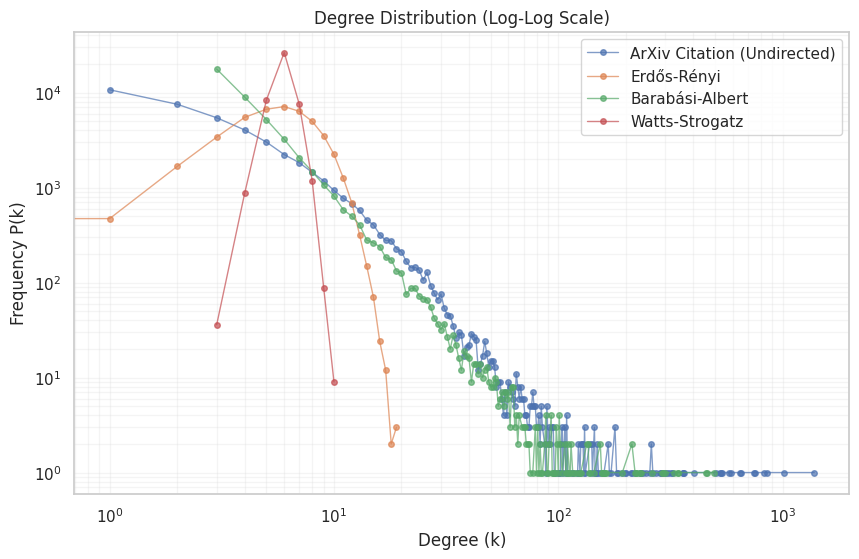

In [27]:
graphs = [G_undir, erdos, barabasi, watts]
labels = ["ArXiv Citation (Undirected)", "Erdős-Rényi", "Barabási-Albert", "Watts-Strogatz"]

network_utils.plot_degree_distribution(graphs, labels)

### Centrality Measures to identify the most impactful papers

In [28]:
titleabs_df = pd.read_csv(
    "titleabs.tsv", 
    sep="\t", 
    header=None, 
    names=["paper id", "title", "abstract"]
)

titleabs_df["paper id"] = titleabs_df["paper id"].astype(int)
titleabs_df = titleabs_df.merge(labels_merged[["paper id", "arxiv category"]], on="paper id")

titleabs_indexed = titleabs_df.set_index("paper id")
titleabs_indexed.head()

,title,abstract,arxiv category
paper id,,,
630234,spreadsheets on the move an evaluation of mobi...,The power of mobile devices has increased dram...,arxiv cs hc
803423,multi view metric learning for multi view vide...,Traditional methods on video summarization are...,arxiv cs cv
1102481,big data analytics in future internet of things,Current research on Internet of Things (IoT) m...,arxiv cs dc
1532644,machine learner for automated reasoning 0 4 an...,Machine Learner for Automated Reasoning (MaLAR...,arxiv cs lg
1810480,cryptographic hardening of d sequences,This paper shows how a one-way mapping using m...,arxiv cs cr


In [29]:
pagerank = nx.pagerank(G)
pagerank_ranking = network_utils.get_top_papers_by_centrality(titleabs_indexed, pagerank, "pagerank", node_mapping)

In [30]:
degree = nx.in_degree_centrality(G)
degree_ranking = network_utils.get_top_papers_by_centrality(titleabs_indexed, degree, "degree", node_mapping)


In [31]:
betweenness = nx.betweenness_centrality(G, k=1000, seed=23)
betweenness_ranking = network_utils.get_top_papers_by_centrality(titleabs_indexed, betweenness, "betweenness", node_mapping)

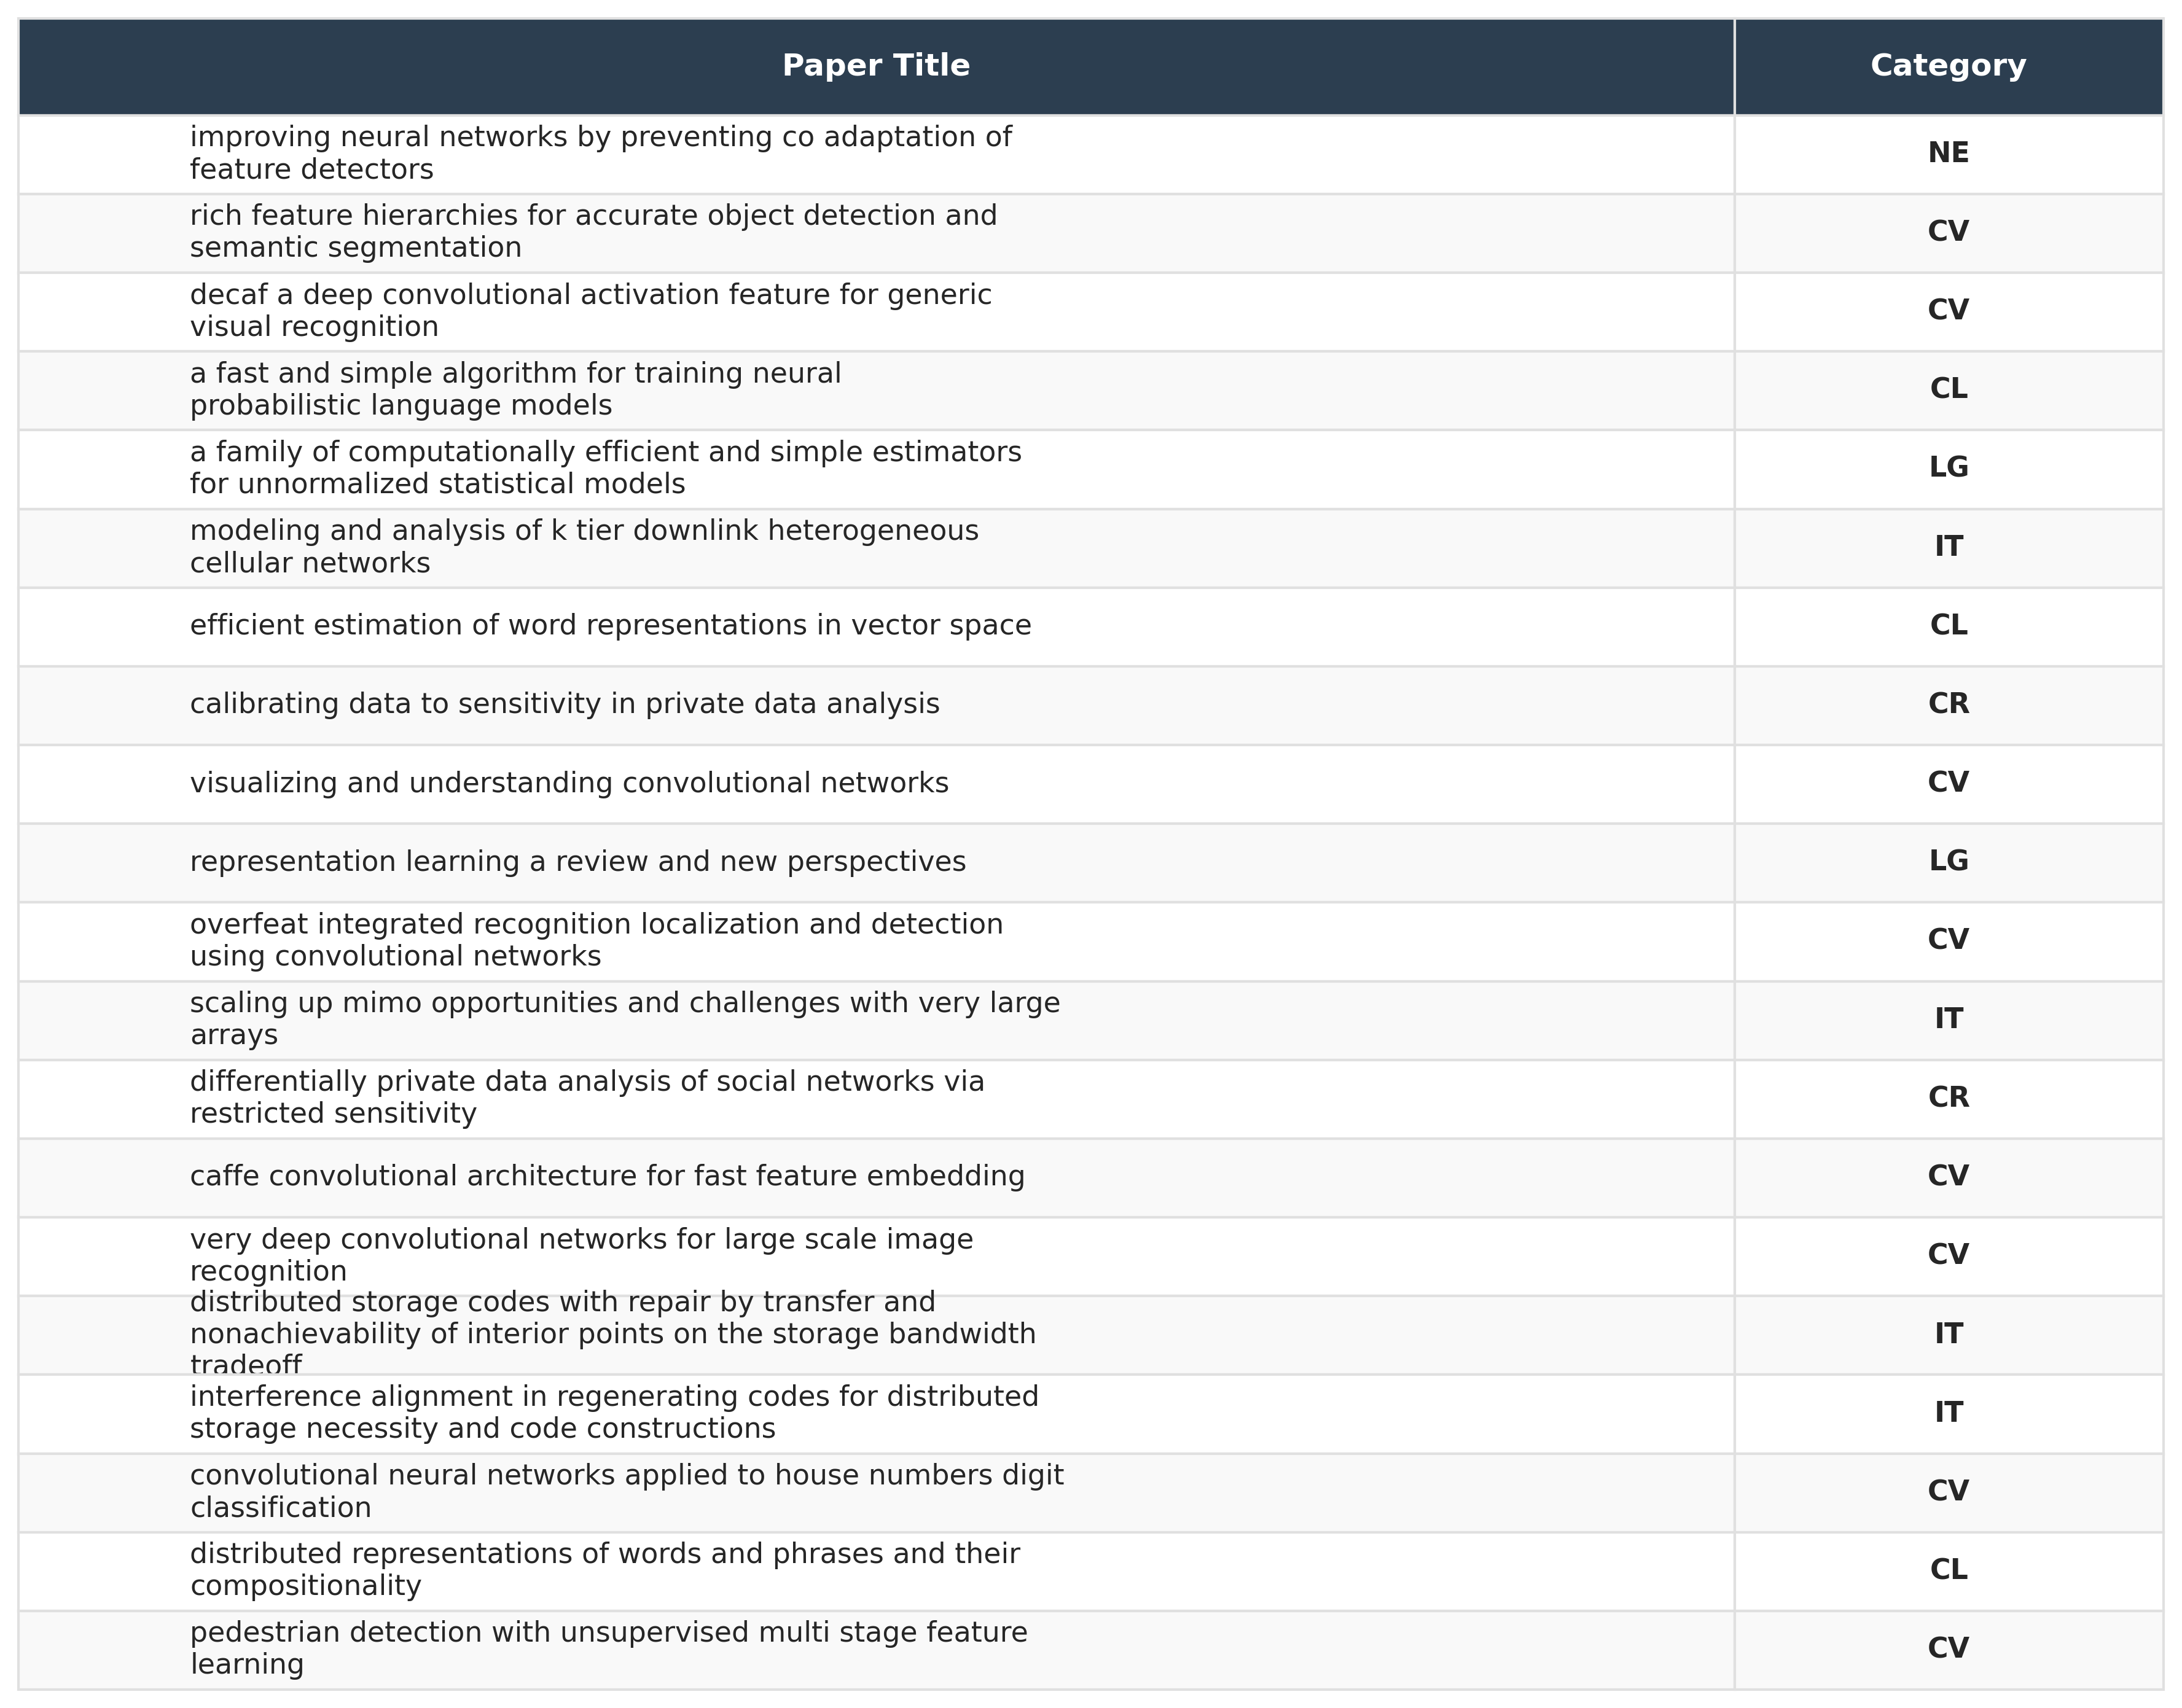

In [32]:
import matplotlib.pyplot as plt
import textwrap

# 1. Use the entire pagerank_ranking table
table_data = pagerank_ranking.copy()

# 2. Clean category name and wrap long titles
table_data["category"] = table_data["arxiv category"].str.replace("arxiv cs ", "").str.upper()
table_data["title_wrapped"] = table_data["title"].map(lambda x: "\n".join(textwrap.wrap(x, width=60)))

# Keep only Title and Category columns
table_df = table_data[["title_wrapped", "category"]].copy()
table_df.columns = ["Paper Title", "Category"]

# 3. Adjust figure height dynamically based on the number of rows
fig_height = 0.8 + 0.45 * len(table_df)
fig, ax = plt.subplots(figsize=(12, fig_height), dpi=300)
ax.axis('off')

# Table styling colors
header_color = '#2c3e50'    # Premium dark blue header
row_colors = ['#f9f9f9', '#ffffff'] # Alternating row colors
edge_color = '#e0e0e0'

tbl = ax.table(
    cellText=table_df.values,
    colLabels=table_df.columns,
    loc='center',
    cellLoc='left',
    colWidths=[0.8, 0.2]     # 80% width for titles, 20% for category
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(11)

# Style cells individually
for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor(edge_color)
    cell.set_linewidth(1)
    
    if row == 0:
        cell.set_text_props(weight='bold', color='white', fontsize=12)
        cell.set_facecolor(header_color)
        cell.set_height(0.08)
    else:
        cell.set_facecolor(row_colors[row % len(row_colors)])
        cell.set_height(0.065)
        # Center-align and bold the categories
        if col == 1:
            cell.set_text_props(weight='semibold', ha='center')

# Center-align the Category header
tbl[0, 1].set_text_props(ha='center')

plt.tight_layout()
plt.show()

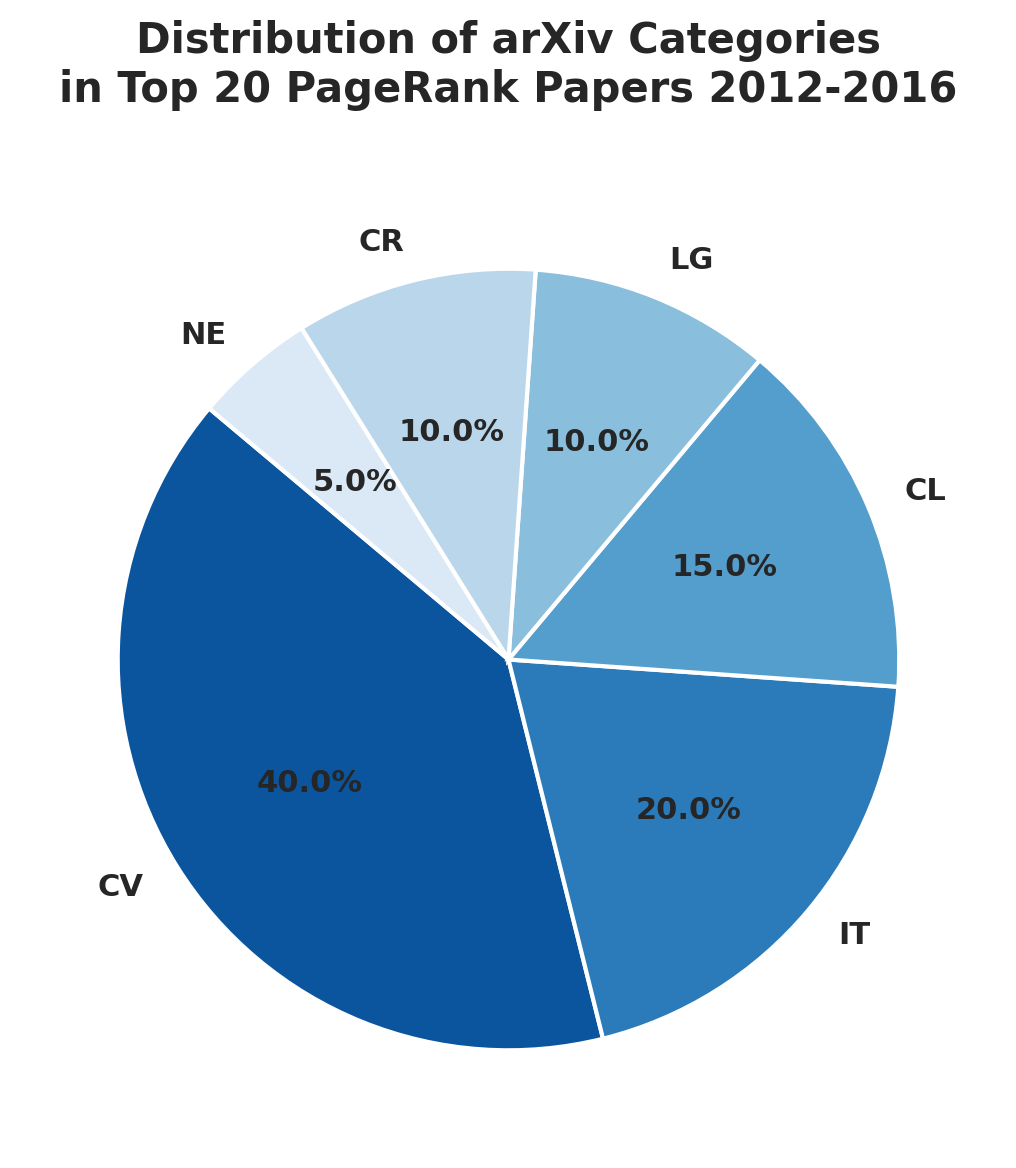

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean, modern aesthetic style
sns.set_theme(style="whitegrid")

# 1. Grab the top 20 papers from the pagerank_ranking DataFrame
top_20_papers = pagerank_ranking.head(20).copy()

# 2. Clean the category names (e.g., "arxiv cs it" -> "IT")
top_20_papers['category'] = top_20_papers['arxiv category'].str.replace('arxiv cs ', '').str.upper()

# 3. Count how many times each category appears in the top 20
category_counts = top_20_papers['category'].value_counts().reset_index()
category_counts.columns = ['category', 'count']

# 4. Generate the Pie Chart
plt.figure(figsize=(6, 6), dpi=200)

# Colors palette
colors = sns.color_palette("Blues_r", len(category_counts))

plt.pie(
    category_counts['count'],
    labels=category_counts['category'],
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5, 'antialiased': True},
    textprops={'fontsize': 11, 'fontweight': 'bold'}
)

plt.title("Distribution of arXiv Categories\nin Top 20 PageRank Papers 2012-2016", fontsize=15, fontweight='bold', pad=25)
plt.tight_layout()
plt.show()


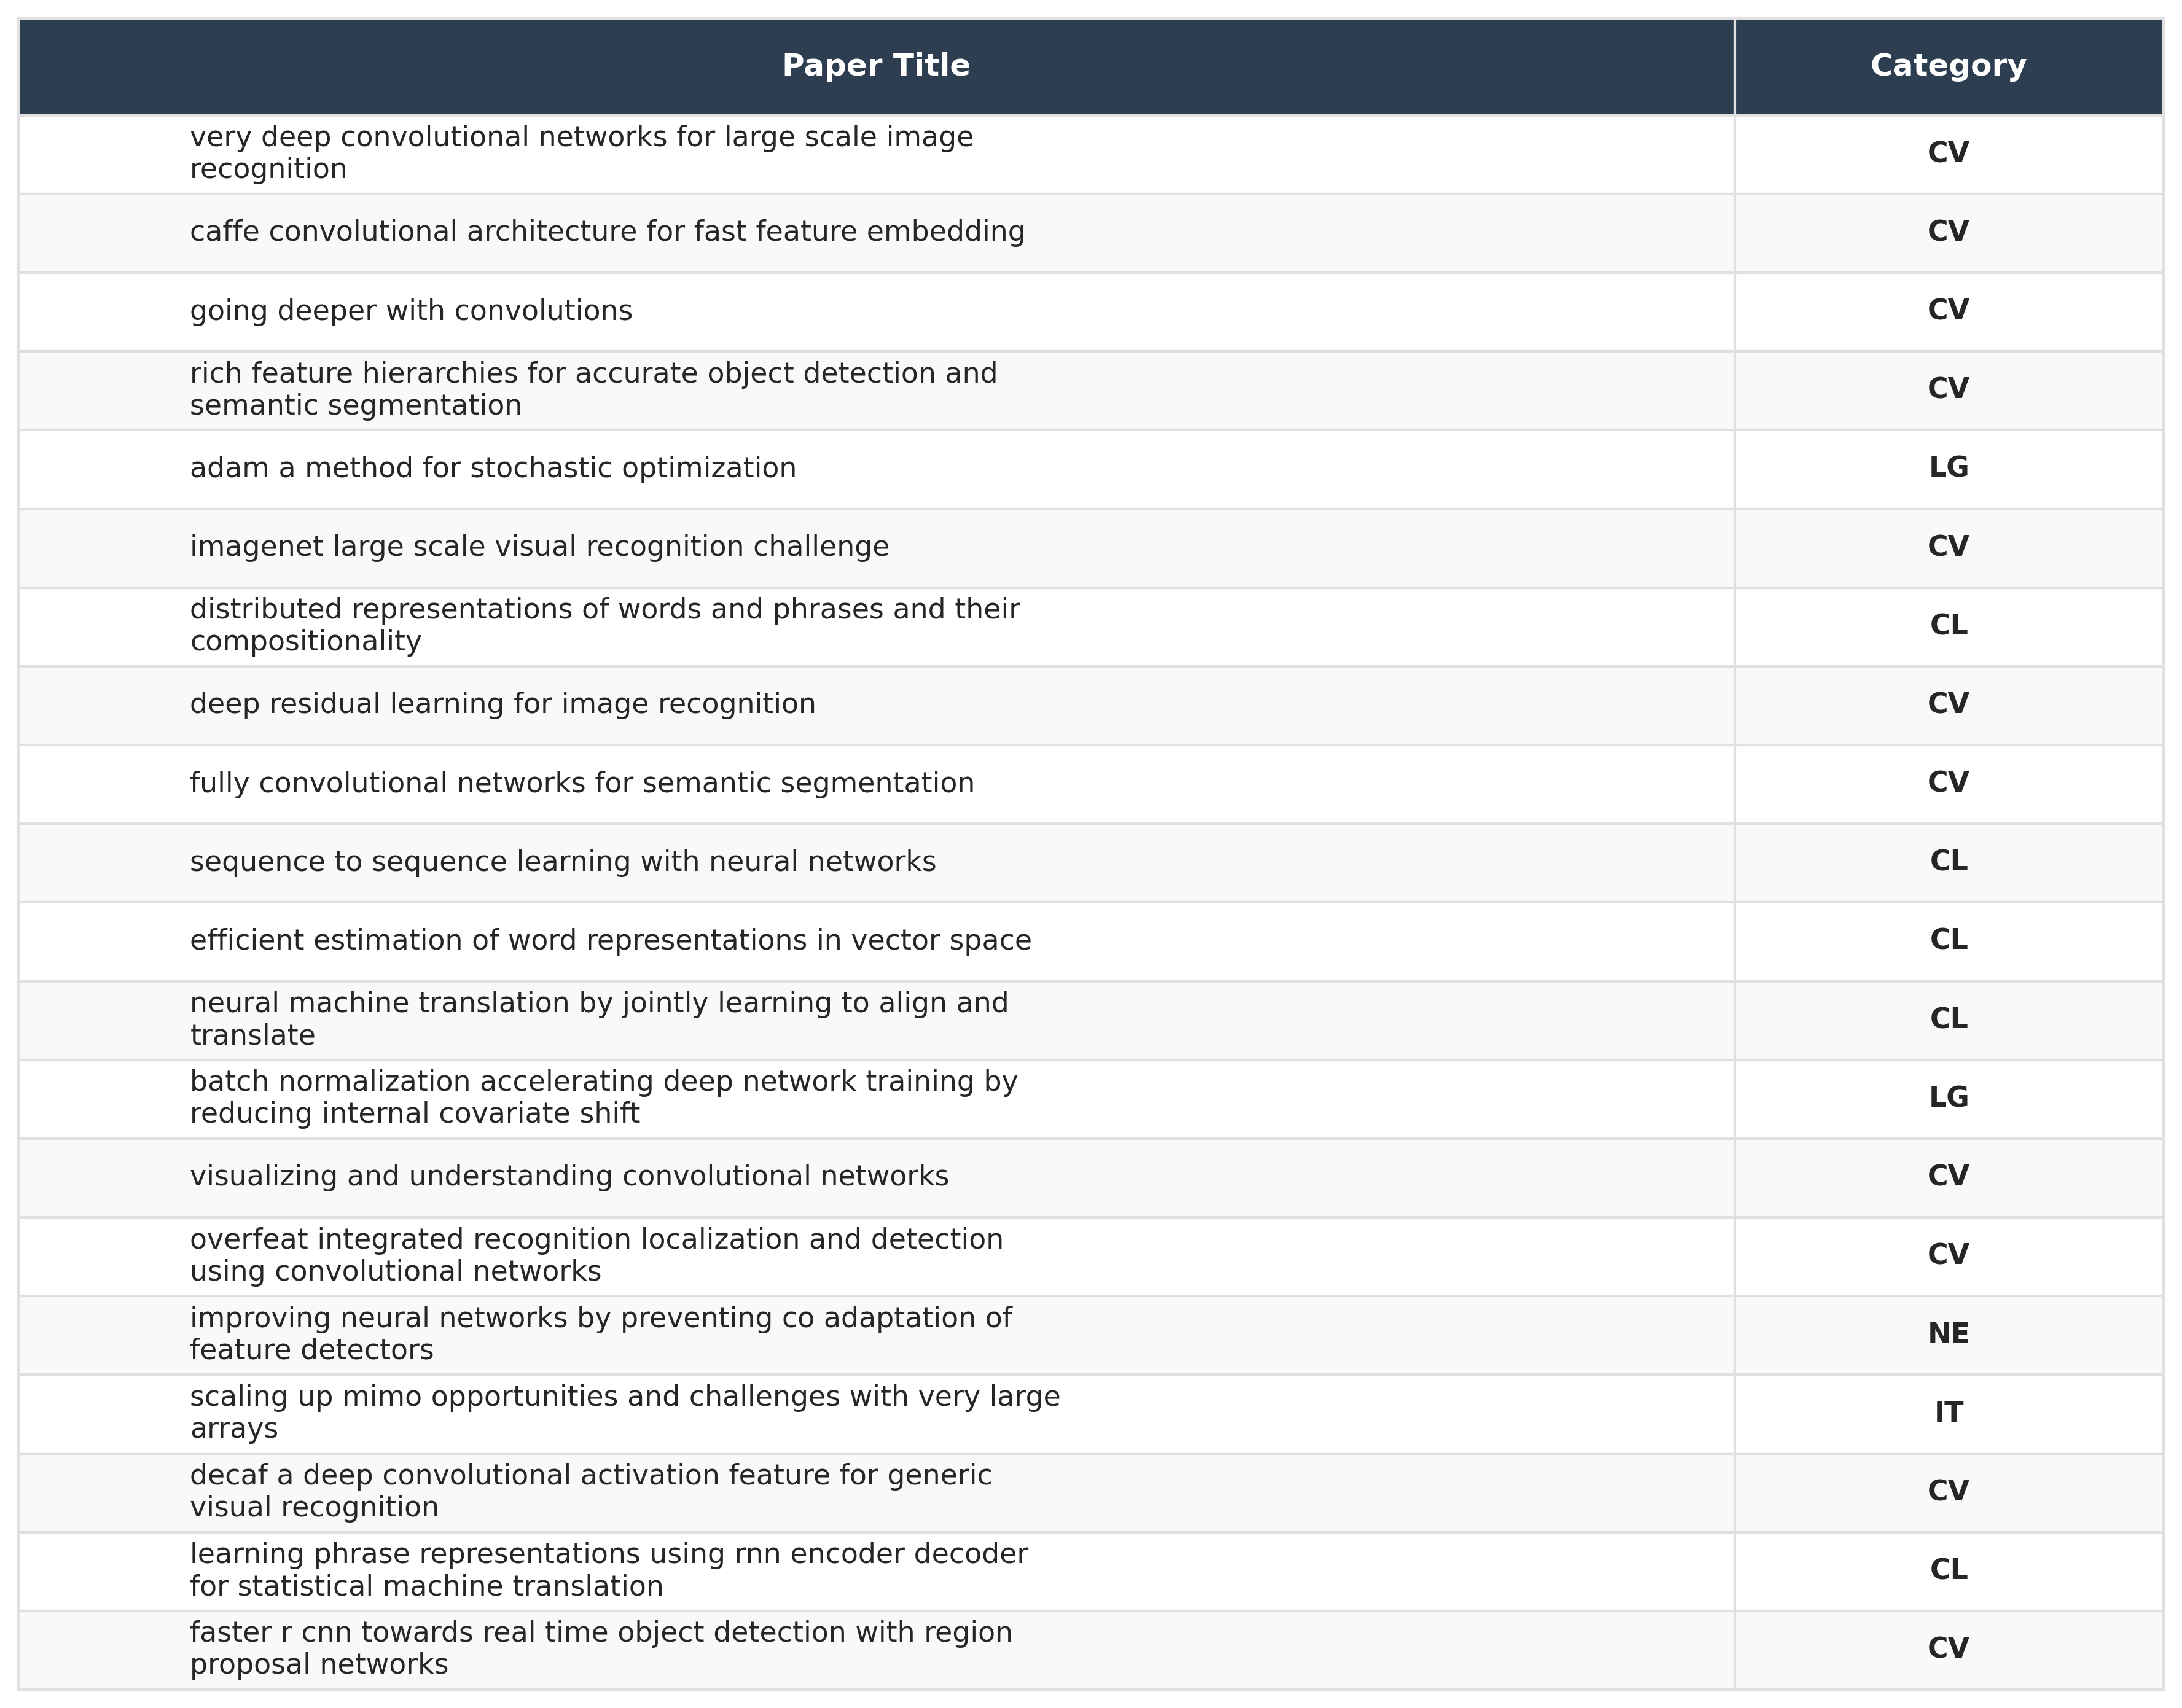

In [34]:
import matplotlib.pyplot as plt
import textwrap

# 1. Use the entire degree_ranking table
table_data = degree_ranking.copy()

# 2. Clean category name and wrap long titles
table_data["category"] = table_data["arxiv category"].str.replace("arxiv cs ", "").str.upper()
table_data["title_wrapped"] = table_data["title"].map(lambda x: "\n".join(textwrap.wrap(x, width=60)))

# Keep only Title and Category columns
table_df = table_data[["title_wrapped", "category"]].copy()
table_df.columns = ["Paper Title", "Category"]

# 3. Adjust figure height dynamically based on the number of rows
fig_height = 0.8 + 0.45 * len(table_df)
fig, ax = plt.subplots(figsize=(12, fig_height), dpi=300)
ax.axis('off')

# Table styling colors
header_color = '#2c3e50'    # Premium dark blue header
row_colors = ['#f9f9f9', '#ffffff'] # Alternating row colors
edge_color = '#e0e0e0'

tbl = ax.table(
    cellText=table_df.values,
    colLabels=table_df.columns,
    loc='center',
    cellLoc='left',
    colWidths=[0.8, 0.2]     # 80% width for titles, 20% for category
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(11)

# Style cells individually
for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor(edge_color)
    cell.set_linewidth(1)
    
    if row == 0:
        cell.set_text_props(weight='bold', color='white', fontsize=12)
        cell.set_facecolor(header_color)
        cell.set_height(0.08)
    else:
        cell.set_facecolor(row_colors[row % len(row_colors)])
        cell.set_height(0.065)
        # Center-align and bold the categories
        if col == 1:
            cell.set_text_props(weight='semibold', ha='center')

# Center-align the Category header
tbl[0, 1].set_text_props(ha='center')

plt.tight_layout()
plt.show()


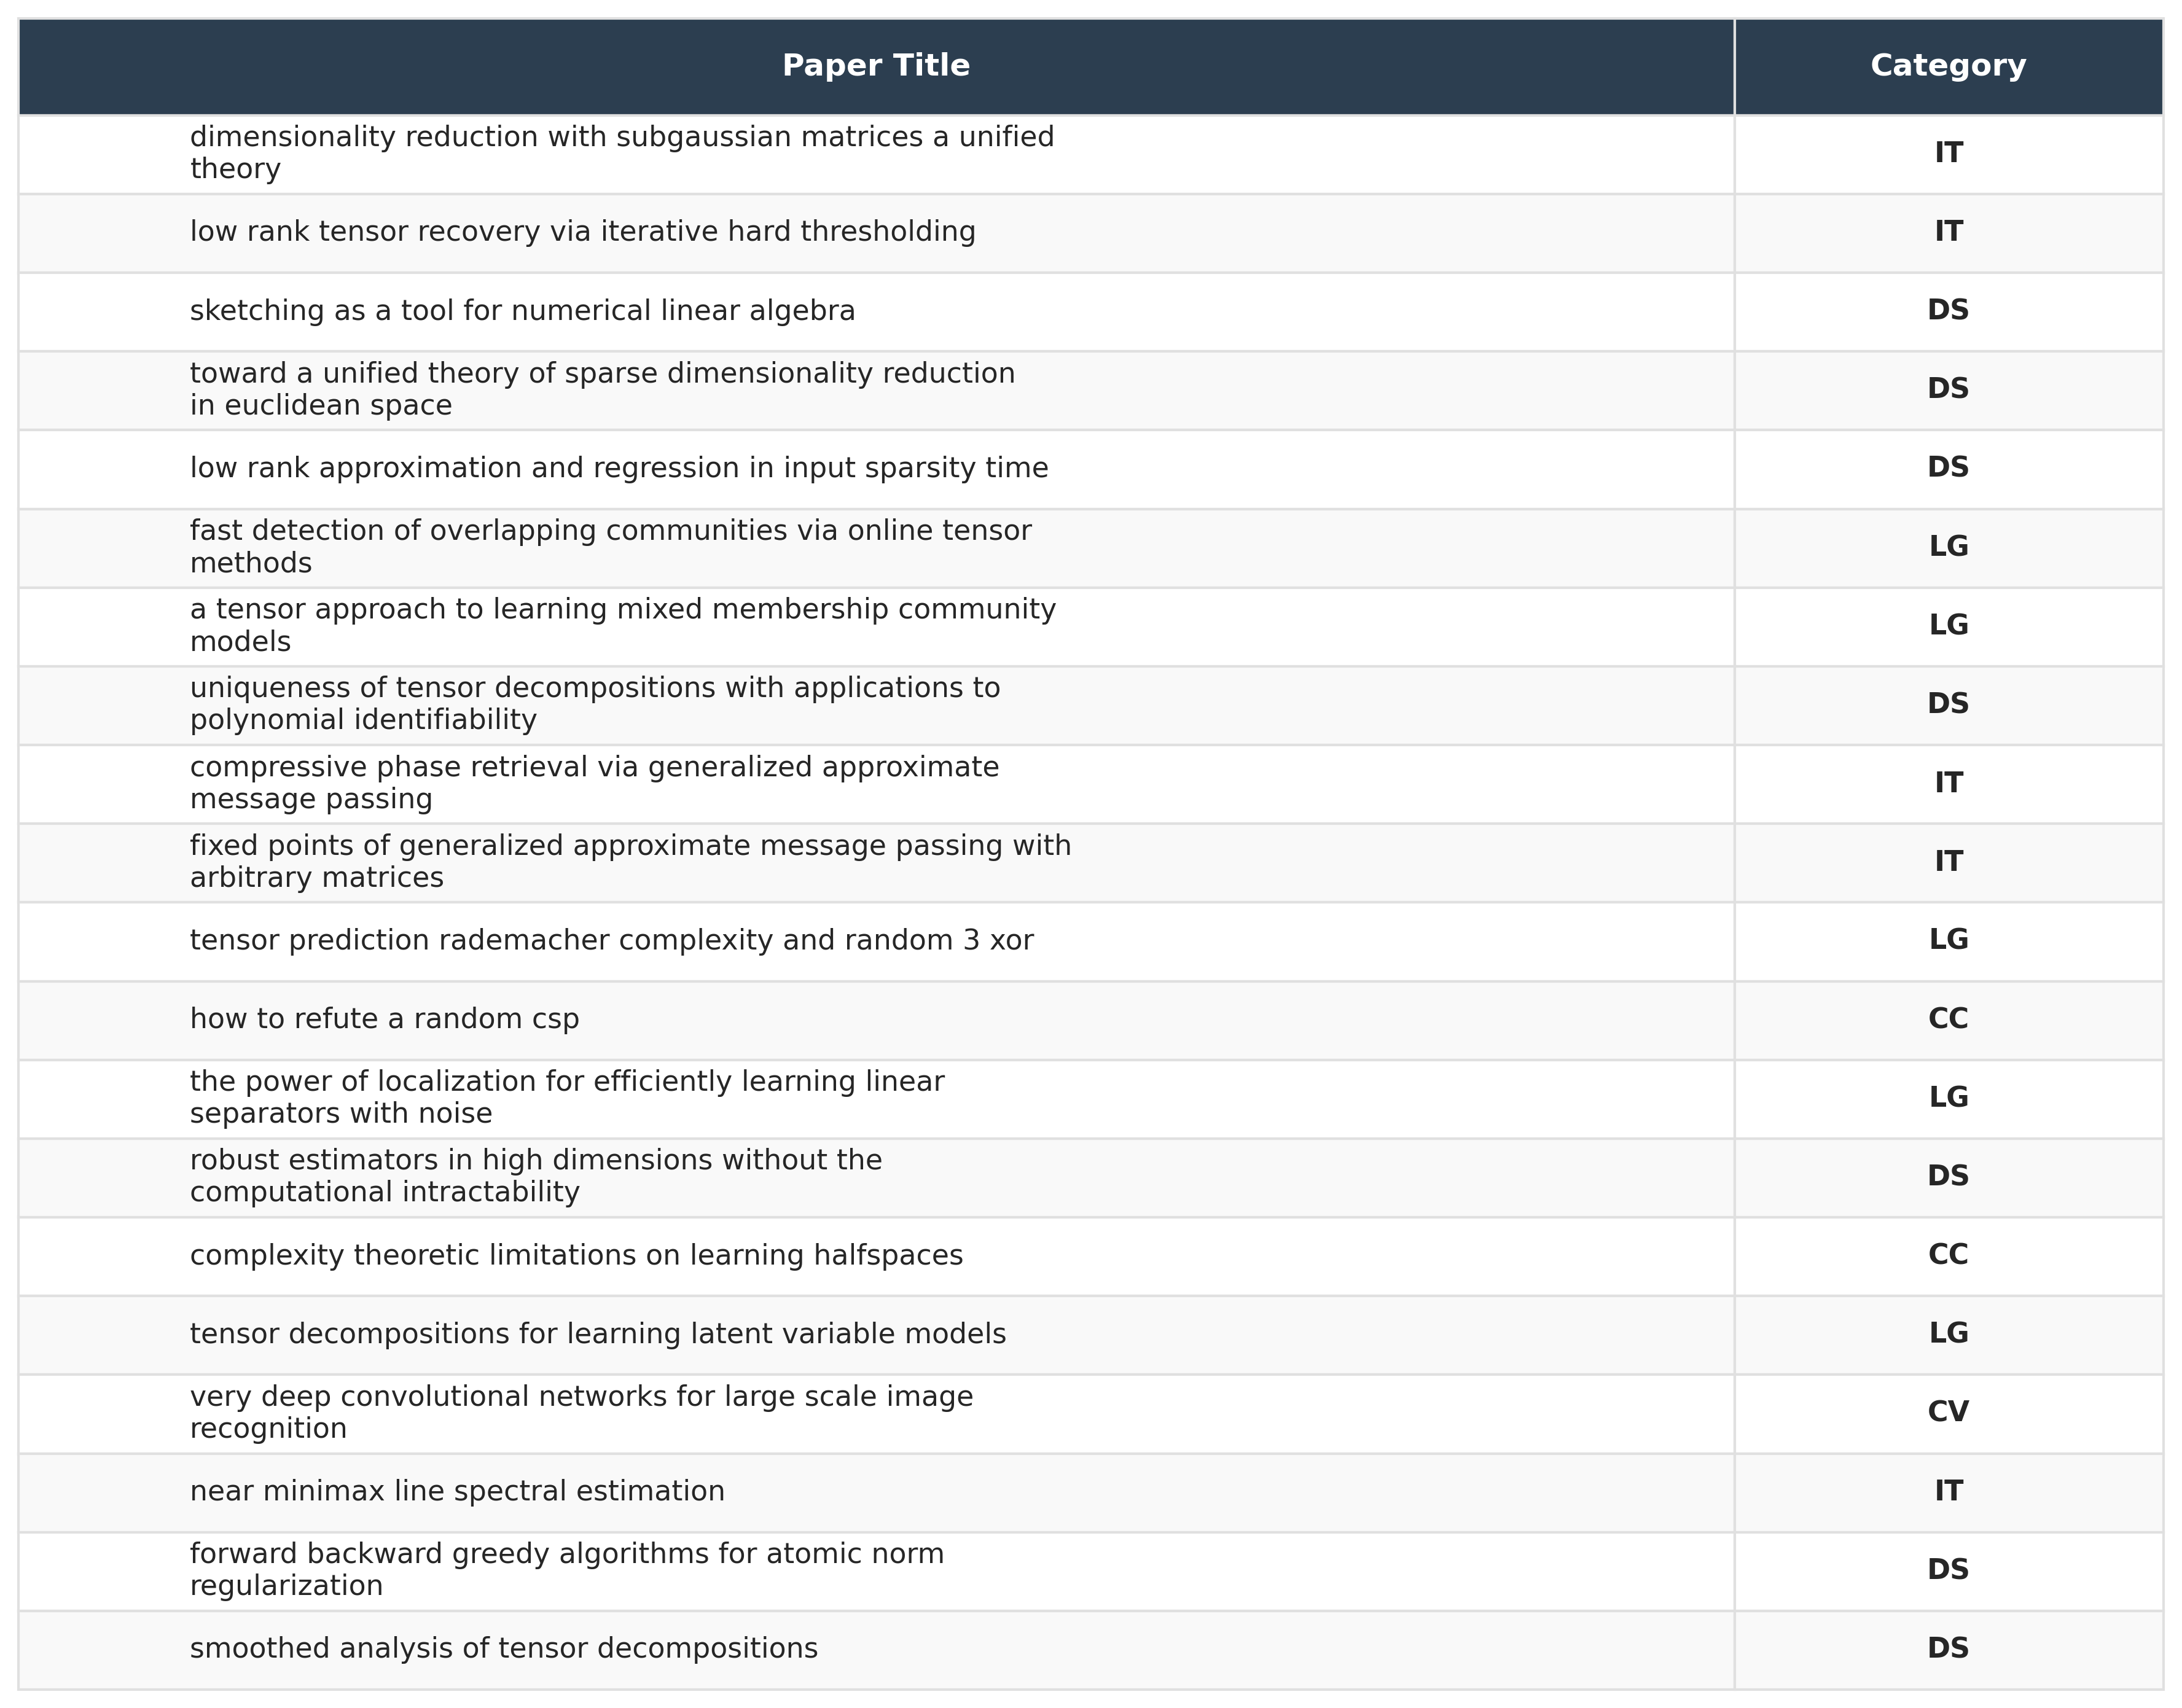

In [35]:
import matplotlib.pyplot as plt
import textwrap

# 1. Use the entire betweenness_ranking table
table_data = betweenness_ranking.copy()

# 2. Clean category name and wrap long titles
table_data["category"] = table_data["arxiv category"].str.replace("arxiv cs ", "").str.upper()
table_data["title_wrapped"] = table_data["title"].map(lambda x: "\n".join(textwrap.wrap(x, width=60)))

# Keep only Title and Category columns
table_df = table_data[["title_wrapped", "category"]].copy()
table_df.columns = ["Paper Title", "Category"]

# 3. Adjust figure height dynamically based on the number of rows
fig_height = 0.8 + 0.45 * len(table_df)
fig, ax = plt.subplots(figsize=(12, fig_height), dpi=300)
ax.axis('off')

# Table styling colors
header_color = '#2c3e50'    # Premium dark blue header
row_colors = ['#f9f9f9', '#ffffff'] # Alternating row colors
edge_color = '#e0e0e0'

tbl = ax.table(
    cellText=table_df.values,
    colLabels=table_df.columns,
    loc='center',
    cellLoc='left',
    colWidths=[0.8, 0.2]     # 80% width for titles, 20% for category
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(11)

# Style cells individually
for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor(edge_color)
    cell.set_linewidth(1)
    
    if row == 0:
        cell.set_text_props(weight='bold', color='white', fontsize=12)
        cell.set_facecolor(header_color)
        cell.set_height(0.08)
    else:
        cell.set_facecolor(row_colors[row % len(row_colors)])
        cell.set_height(0.065)
        # Center-align and bold the categories
        if col == 1:
            cell.set_text_props(weight='semibold', ha='center')

# Center-align the Category header
tbl[0, 1].set_text_props(ha='center')

plt.tight_layout()
plt.show()


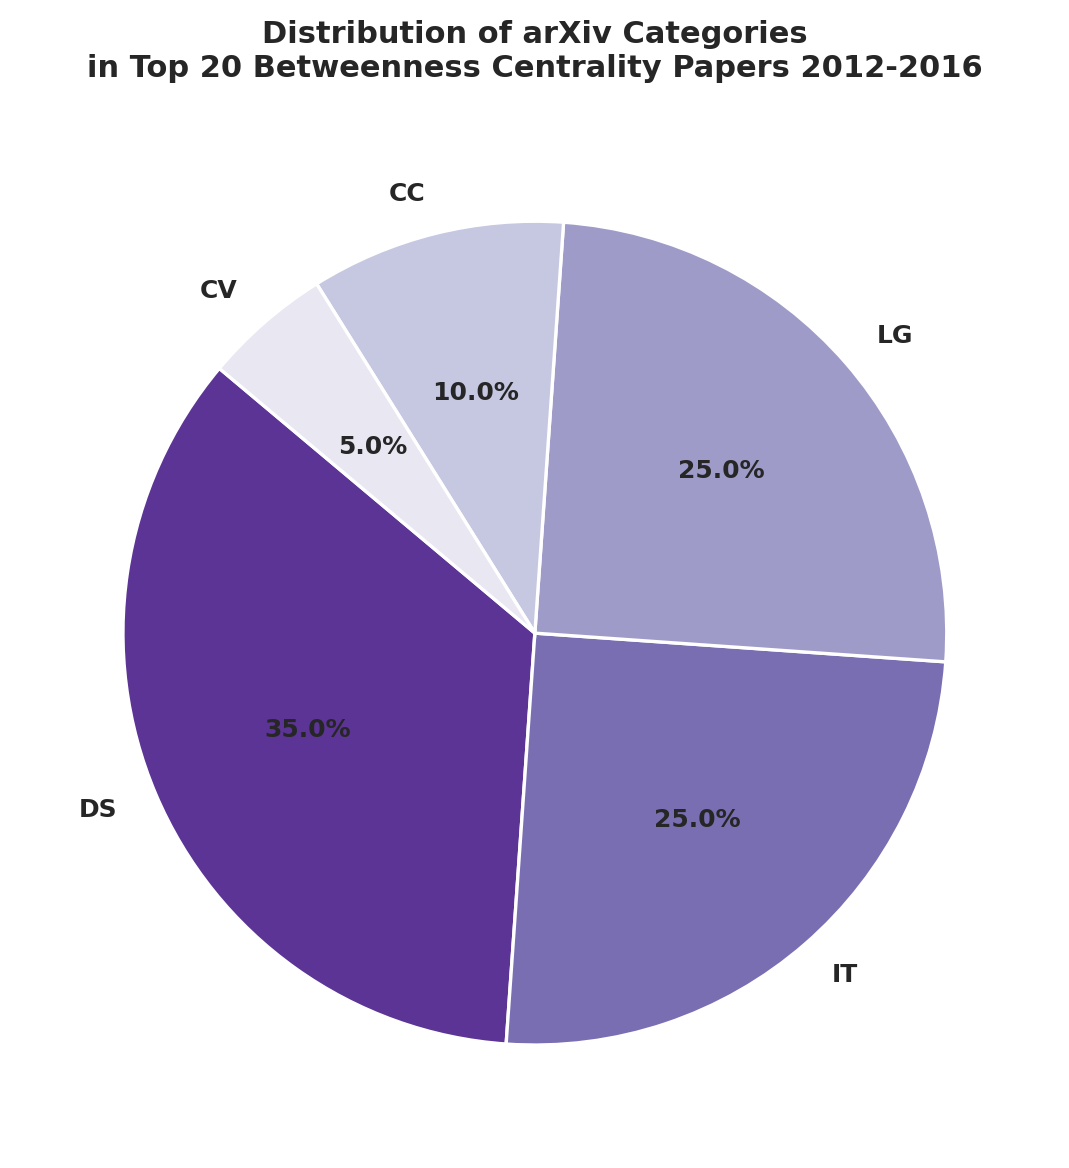

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean, modern aesthetic style
sns.set_theme(style="whitegrid")

# 1. Grab the top 20 papers from the betweenness_ranking DataFrame
top_20_papers_bt = betweenness_ranking.head(20).copy()

# 2. Clean the category names
top_20_papers_bt['category'] = top_20_papers_bt['arxiv category'].str.replace('arxiv cs ', '').str.upper()

# 3. Count how many times each category appears in the top 20
category_counts_bt = top_20_papers_bt['category'].value_counts().reset_index()
category_counts_bt.columns = ['category', 'count']

# 4. Generate the Pie Chart
plt.figure(figsize=(6, 6), dpi=200)

# Using a distinct color palette (Purples_r) to differentiate from the PageRank chart
colors = sns.color_palette("Purples_r", len(category_counts_bt))

plt.pie(
    category_counts_bt['count'],
    labels=category_counts_bt['category'],
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.2, 'antialiased': True},
    textprops={'fontsize': 9, 'fontweight': 'bold'}
)

plt.title("Distribution of arXiv Categories\nin Top 20 Betweenness Centrality Papers 2012-2016", fontsize=11, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()
